# Fake News Detection system

In [1]:
import pandas as pd

FAKE_PATH = "/content/drive/MyDrive/project-2026/proj-4/data/Fake.csv"
TRUE_PATH = "/content/drive/MyDrive/project-2026/proj-4/data/True.csv"

fake = pd.read_csv(FAKE_PATH)
true = pd.read_csv(TRUE_PATH)

fake["label"] = 0   # Fake
true["label"] = 1   # Real

df = pd.concat([fake, true], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


## Cleaning Text

In [2]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["text"].apply(clean_text)


## Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 35918
Test size: 8980


##NLP Model (TF-IDF + Linear SVM)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        ngram_range=(1,2)
    )),
    ("clf", LinearSVC())
])

model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


##Evaluation

Accuracy: 0.9959910913140312

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4696
           1       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



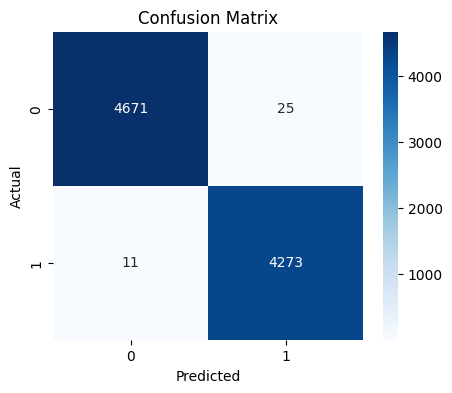

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [6]:
import joblib
import os

BASE_DIR = "/content/drive/MyDrive/project-2026/proj-4"
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model, os.path.join(MODEL_DIR, "fake_news_detector.pkl"))

print("Model saved successfully!")


Model saved successfully!


In [7]:
model = joblib.load(
    "/content/drive/MyDrive/project-2026/proj-4/models/fake_news_detector.pkl"
)

print("Model loaded!")


Model loaded!


##Testing model On Custom News

In [8]:
sample_news = """
Breaking: Government announces new economic reform package
to stabilize inflation and boost employment.
"""

prediction = model.predict([clean_text(sample_news)])

if prediction[0] == 1:
    print("Prediction: REAL News")
else:
    print("Prediction: FAKE News")


Prediction: FAKE News


In [ ]:
# Run this in a Colab cell before downloading
!pip install nbformat

!ls "/content/drive/MyDrive/Colab Notebooks/"

import nbformat
import json

# Read your notebook
with open("/content/drive/MyDrive/Colab Notebooks/Proj4.ipynb", 'r') as f:
    nb = nbformat.read(f, as_version=4)

# Remove widget metadata
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

# Save the cleaned notebook
with open('/content/Edit_percentage.ipynb', 'w') as f:
    nbformat.write(nb, f)

print("Notebook cleaned! Download 'your_notebook_cleaned.ipynb'")